# 2. mRNA display: CCL22 selection

This notebook demonstrates the use of clibas to analyze mRNA display library selections using data from Payne and co-workers as an example.

For further details and the source of data, see [B. Zhang et al. Discovery of Selective Cyclic D‑Sulfopeptide Ligands of the
Chemokine CCL22 via Mirror-Image mRNA Display with Genetic Reprogramming. J. Am. Chem. Soc. 2024, 146, 34253−34259](https://pubs.acs.org/doi/10.1021/jacs.4c12057)

In the paper, the authors design and screen mRNA display libraries of cyclic peptides containing non-standard sulfo-tyrosine amino acids. Additionally, the cyclization is achieved with the use of N-chloroacetylated amino acids used for translation initiation. The electrophilic chloroacetyl moiety spontaneously cyclizes with a downstream cysteine residue to yield thioether-closed macrocyclic structures. Currently, this is one of the most common cyclization strategies employed in mRNA display selections.  

The authors released NGS data for the first seven rounds of selection against mirror image CCL22 (D-CCL22), which was chemically synthesized. The NGS-derived DNA reads look something like this:

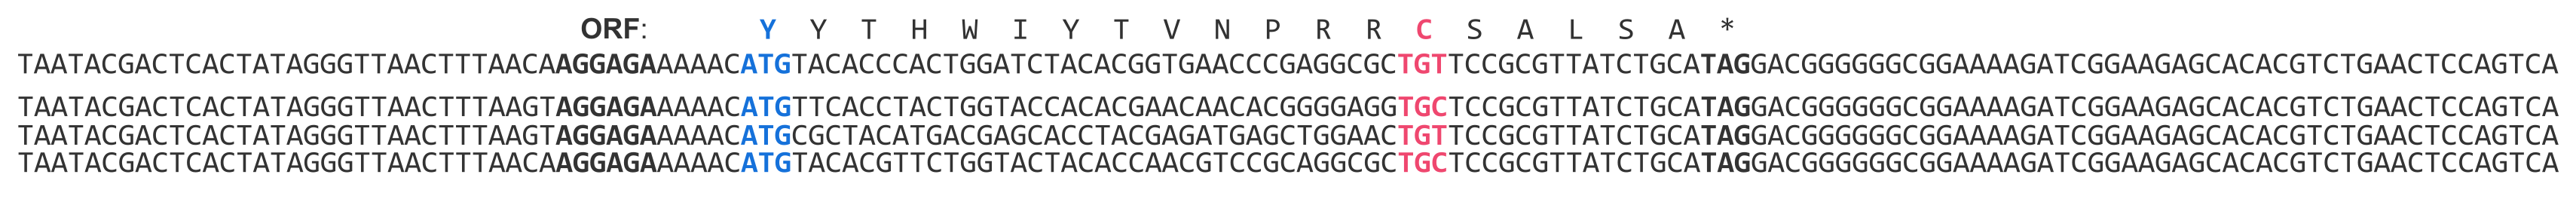

The reads, provided in single-end format, cover the entire ORF and start with a defined constant 5' sequence. This makes their parsing relatively easy. The peptide library design features an N-terminal Cl-Ac-L-Tyr (non-canonical translation initiation), followed by a random region of variable length encoded by an (NNS)<sub>x</sub> (x=4-15) insert. The C-terminal sequence contains a cysteine residue used for cyclization, and "SALSA" as a linker. This design allows us to write DNA and peptide library templates for a clibas pipeline like this:

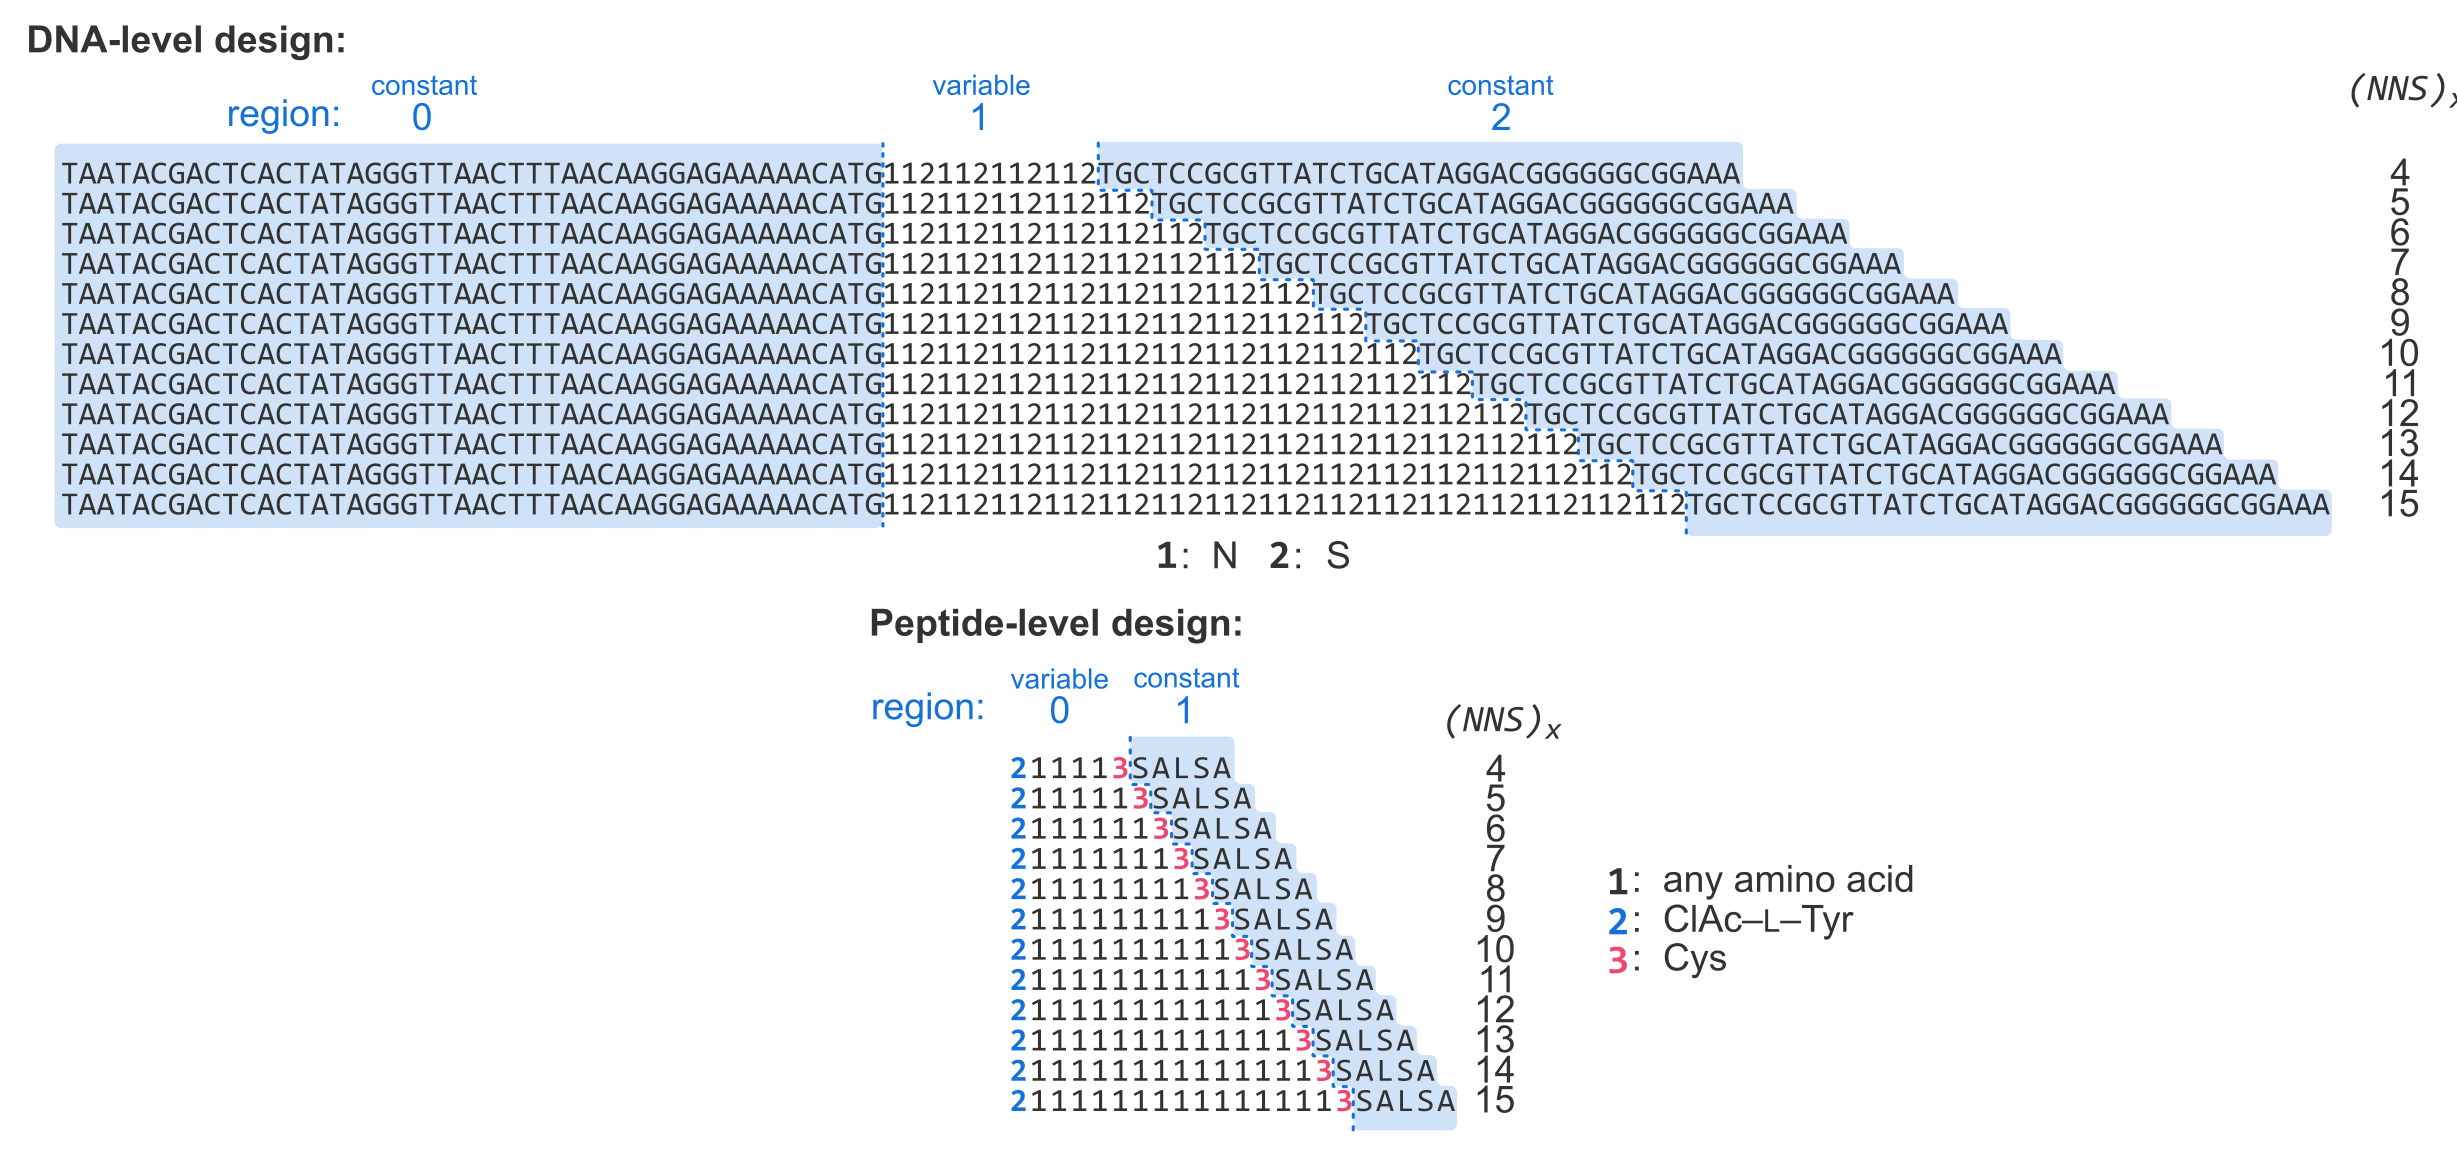

Note that the N-terminal Cl-Ac-L-Tyr could be broken into a separate constant region of length 1, and the cysteine could instead be specified as part of the C-terminal constant region. In other words, peptide templates can also be specified like this: `Y111111CSALSA`. It is a matter of preference. Specifying the designs as `21111113SALSA` allows us to later call `C.fastq_parser.vr_filter(where='pep', loc=[0], sets=[1, 2, 3])` to ensure that all peptide sequences lacking the C-terminal cysteine are discarded. 

To write a `.yaml` config file for these libraries, we also need to specify a custom translation table where the `ATG` elongation codon encodes sulfo-tyrosine (denoted as `y` in this example), and provide the `custom_ini_aa` to account for the non-standard translation initiator amino acid. Specifying `aa_SMILES` allows us to later run UMAP/HDBSCAN analysis using extended connectivity fingerprint representations of peptide sequences. If not provided, the operation can still be called but the peptides will need to be one-hot encoded. 

In addition, we specify `orf_locator`: `"AGGAGA.....ATG"`. This helps the parser locate the ORF at the 5' end of the reads. This is optional. If not specified, `"ATG"` will be used to locate ORFs which works fine most of the time. `TrackerConfig` and `LoggerConfig` specifications are also optional.

```yaml
experiment: "Payne_CCL22_selection"

constants:
  description: |
    Star symbol (*) is internally reserved for stop codons that terminate
    translation.
    
    Plus and underscore symbols (+ and _) are internally reserved tokens.
    Numerals (1234567890) are internally reserved for library design 
    specifications. These symbols (123456790+_) should not be used to
    encode amino acids.
    
    Other symbols are OK.   
    
  translation_table:
    ATA: "I"
    ATC: "I"
    ATT: "I"
    ATG: "y"
    ACA: "T"
    ACC: "T"
    ACG: "T"
    ACT: "T"
    AAC: "N"
    AAT: "N"
    AAA: "K" 
    AAG: "K"
    AGC: "S"
    AGT: "S"
    AGA: "R"
    AGG: "R"
    CTA: "L" 
    CTC: "L"
    CTG: "L"
    CTT: "L"
    CCA: "P" 
    CCC: "P" 
    CCG: "P" 
    CCT: "P"
    CAC: "H"
    CAT: "H" 
    CAA: "Q" 
    CAG: "Q"
    CGA: "R"
    CGC: "R"
    CGG: "R"
    CGT: "R"
    GTA: "V" 
    GTC: "V" 
    GTG: "V"
    GTT: "V"
    GCA: "A" 
    GCC: "A" 
    GCG: "A" 
    GCT: "A"
    GAC: "D" 
    GAT: "D"
    GAA: "E" 
    GAG: "E"
    GGA: "G" 
    GGC: "G"
    GGG: "G"
    GGT: "G"
    TCA: "S" 
    TCC: "S" 
    TCG: "S"
    TCT: "S"
    TTC: "F" 
    TTT: "F" 
    TTA: "L" 
    TTG: "L"
    TAC: "Y" 
    TAT: "Y" 
    TAA: "*" 
    TAG: "*"
    TGC: "C"
    TGT: "C" 
    TGA: "*" 
    TGG: "W"

  custom_ini_aa: "Y"     
  
  aa_SMILES:
    A: "N[C@@H](C)C(=O)"           
    C: "N[C@@H](CS)C(=O)"
    D: "N[C@@H](CC(=O)O)C(=O)"
    E: "N[C@@H](CCC(=O)O)C(=O)"
    F: "N[C@@H](Cc1ccccc1)C(=O)"
    G: "NCC(=O)"
    H: "N[C@@H](Cc1c[nH]cn1)C(=O)"
    I: "N[C@@H]([C@H](CC)C)C(=O)"
    K: "N[C@@H](CCCCN)C(=O)"       
    L: "N[C@@H](CC(C)C)C(=O)"
    N: "N[C@@H](CC(=O)N)C(=O)"
    P: "O=C[C@@H]1CCCN1"
    Q: "N[C@@H](CCC(=O)N)C(=O)"
    R: "N[C@@H](CCCNC(=N)N)C(=O)"
    S: "N[C@@H](CO)C(=O)"
    T: "N[C@@H]([C@H](O)C)C(=O)"
    V: "N[C@@H](C(C)C)C(=O)"
    W: "N[C@@H](Cc1c[nH]c2c1cccc2)C(=O)"
    Y: "N[C@@H](Cc1ccc(O)cc1)C(=O)"
    y: "N[C@@H](CC1=CC=C(OS(O)(=O)=O)C=C1)C=O"
    
  complement_table:
    - "ATCGN"
    - "TAGCN"
    
LibraryDesigns:
  dna_templates:
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    - "TAATACGACTCACTATAGGGTTAACTTTAACAAGGAGAAAAACATG112112112112112112112112112112112112112112112TGCTCCGCGTTATCTGCATAGGACGGGGGGCGGAAA"
    
  dna_monomers:
    1: ["A", "G", "T", "C"] #N
    2: ["G", "C"] #S
    
  pep_templates:
    - "211113SALSA"
    - "2111113SALSA"
    - "21111113SALSA"
    - "211111113SALSA"
    - "2111111113SALSA"
    - "21111111113SALSA"
    - "211111111113SALSA"
    - "2111111111113SALSA"
    - "21111111111113SALSA"
    - "211111111111113SALSA"  
    - "2111111111111113SALSA"
    - "21111111111111113SALSA"    
    
  pep_monomers:
    1: ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "y", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]
    2: ["Y"]
    3: ["C"]

TrackerConfig:
  logs: "./outputs/Payne_CCL22"                 # Directory for writing logs to
  parser_out: "./outputs/Payne_CCL22"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Payne_CCL22"         # Directory that stores outputs of data analysis operations
  
LoggerConfig:
  verbose: true                     # Verbose loggers print to the console
  log_to_file: false                # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"

FastqParserConfig:
  orf_locator: "AGGAGA.....ATG"     # A regex pattern that has to match to initiate the ORF
```

To build a pipeline for these designs, we first intialize clibas facade using this config file. In this case, the `Payne_CCL22_config.yaml` is placed in the same directory as this notebook.

In [1]:
import clibas as C
C.initialize(config_path='Payne_CCL22_config.yaml')

[INFO]: <clibas> succesfully loaded config and is ready. . .


Now we can build the pipeline. We trim the reads at the 3' (optional), translate them to DNA right after, and process from there. 
A few things to note:

> i) we collect DNA/peptide lengths before doing any filtering to see an unbiased distribution of reads.
>  
> ii) the `count_summary` operation is called multiple times:  
> - first, before doing any filtering to see the "raw" composition of the library at the peptide level 
> - then at the end, after removing noise, to generate both `.csv` and `.fasta` files for the most enriched peptides.
> 
> iii) we call `umap_hdbscan_analysis` to see how the resulting peptides cluster after all processing is done. It is discussed in more detail below. 

In [2]:
C.pipeline.enque(
    
[
    # trim DNA reads 
    C.fastq_parser.trim_reads(left='', right='GGCGGAAA', tol=1), 
    
    # translate DNA -> peptide, use the ORF_locator to find ORFs
    C.fastq_parser.translate(stop_readthrough=False),

    # length analysis of trimmed DNA reads and the resulting peptides
    # we do it before filtering any reads to get an unbiased view
    C.analysis_tools.length_analysis(where='pep'),
    C.analysis_tools.length_analysis(where='dna'),
    
    # analyze average Phred quality scores
    # we do it before filtering any reads to get an unbiased view
    C.analysis_tools.q_score_analysis(loc=None),

    # count the peptides before doing any filtrtion
    C.fastq_parser.count_summary(where='pep', top_n=1000, fmt='csv'),

    # discard the peptides of incorrect length (incompatible with library designs)
    C.fastq_parser.len_filter(where='pep'),
    
    # discard the peptides with incorrect/overly mutated constant regions
    # up to 3 mutations are tolerated
    C.fastq_parser.cr_filter(where='pep', loc=[1], tol=3),

    # discard the peptides contained unallowed monomers in the variable region
    C.fastq_parser.vr_filter(where='pep', loc=[0], sets=[1, 2, 3]),

    # discard the DNA with average Q scores below 30 in region 0 (random insert region)
    C.fastq_parser.q_score_filt(avgQ=30, loc=[0]),

    # clip peptide sequences to region 0 (random insert region)
    C.fastq_parser.fetch_at(where='pep', loc=[0]),

    # discard all peptides containing any ambiguous amino acids 
    # stemming from N nucleotide base calling etc
    C.fastq_parser.filt_ambiguous(where='pep'),

    # analyze the convergence of the peptide library at the sequence level
    C.analysis_tools.sequence_convergence_analysis(where='pep'),

    # analyze the convergence of the peptide/DNA library at the token level
    # by token, we mean amino acid/nucleotide: basically positional freq analysis
    C.analysis_tools.token_convergence_analysis(where='pep', loc=None),
    C.analysis_tools.token_convergence_analysis(where='dna', loc=None),

    # unpad all arrays: optional, maybe used to free up some memory; not really needed in this case
    C.fastq_parser.unpad(),

    # save the peptide datasets as numpy .npy files - if any downstream analysis in python is envisioned
    C.fastq_parser.save(where='pep', fmt='npy'),

    # count peptides/DNA again - this time after all filtration ops have been called
    C.fastq_parser.count_summary(where='pep', top_n=1000, fmt='csv'),
    C.fastq_parser.count_summary(where='pep', top_n=100, fmt='fasta'),
    C.fastq_parser.count_summary(where='dna', top_n=1000, fmt='csv'),
    C.fastq_parser.count_summary(where='dna', top_n=100, fmt='fasta'),

    # make a table showing the number of reads belonging to each individual 
    # library template for every sample in the batch
    C.fastq_parser.library_design_match(where='pep'),

    # make one joint peptide count summary - track peptides from sample to sample
    C.fastq_parser.dataset_wide_count_summary(where='pep', top_n=2000),
    
    # run UMAP/HDBSCAN analysis on top 1000 peptides; use ECFP4 representation,
    # and embed all samples onto a single manifold for consistency
    C.analysis_tools.umap_hdbscan_analysis(top_n=1000,
                                           where='pep',
                                           F='pep_ECFP4', 
                                           single_manifold=True,
                                           return_modified=False
    )
]
)

[INFO]: 24 ops appended to pipeline; current queue size: 24


Note that at this stage, no data processing has taken place. The pipeline only asserts the validity of the passed arguments, and their consistency with the specified library designs.

To run the analysis, we need to specify a data loader, and then execute the pipeline. In this case, the data is provided as unzipped `.fastq` files, so we use `C.data_loader.fetch_fastq_from_dir` to load it (as opposed to `C.data_loader.fetch_gz_from_dir` which is used to load `.fastq.gz` files). These `.fastq` files should be located in a directory as specified by the `data_dir` keyword: `'./sequencing_data/Payne_CCL22'` in this case. The pipeline will fetch _all_ `.fastq` files from this folder. 

In [3]:
loader = C.data_loader.fetch_fastq_from_dir(data_dir='./sequencing_data/Payne_CCL22')
C.pipeline.load_and_run(loader=loader, save_summary=True)

[INFO]: Queuing <fetch_dir_fastq> op. . .
[INFO]: Fetching DCCL22_r1.fastq. . .
[INFO]: Fetching DCCL22_r2.fastq. . .
[INFO]: Fetching DCCL22_r3.fastq. . .
[INFO]: Fetching DCCL22_r4.fastq. . .
[INFO]: Fetching DCCL22_r5.fastq. . .
[INFO]: Fetching DCCL22_r6.fastq. . .
[INFO]: Fetching DCCL22_r7.fastq. . .
[INFO]: The operation took 1.745 s
[INFO]: DCCL22_r1 dataset size: 140263
[INFO]: DCCL22_r2 dataset size: 124194
[INFO]: DCCL22_r3 dataset size: 156584
[INFO]: DCCL22_r4 dataset size: 177065
[INFO]: DCCL22_r5 dataset size: 176882
[INFO]: DCCL22_r6 dataset size: 160607
[INFO]: DCCL22_r7 dataset size: 153025
[INFO]: -----------------------------------------------------------------
[INFO]: Queuing <trim_exp> op. . .
[INFO]: The operation took 2.601 s
[INFO]: DCCL22_r1 dataset size: 140263
[INFO]: DCCL22_r2 dataset size: 124194
[INFO]: DCCL22_r3 dataset size: 156584
[INFO]: DCCL22_r4 dataset size: 177065
[INFO]: DCCL22_r5 dataset size: 176882
[INFO]: DCCL22_r6 dataset size: 160607
[INFO]

<Data container holding 7 samples>:
<SequencingSample DCCL22_r1 containing 79957 entries>
<SequencingSample DCCL22_r2 containing 70565 entries>
<SequencingSample DCCL22_r3 containing 85548 entries>
<SequencingSample DCCL22_r4 containing 91204 entries>
<SequencingSample DCCL22_r5 containing 76942 entries>
<SequencingSample DCCL22_r6 containing 57750 entries>
<SequencingSample DCCL22_r7 containing 64462 entries>

This example demonstrates the difficulties of reproducing NGS analysis results even when data is made publicly available. Our results are significantly different from what the authors report.

Below is a table from the paper showing the top-25 peptide sequences and their abundance (ignore the lower case sequence notation, it is not important here). The non-standard sulfo-tyrosine is represented as `x`:

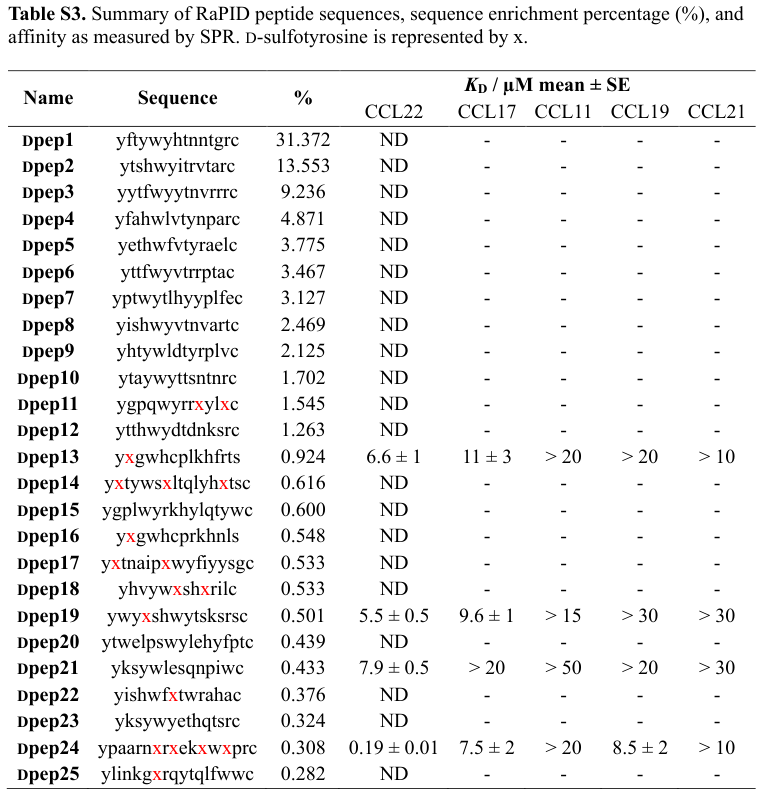

Peptide `YFTYWYHTNNTGRC` is the top-1 selection hit; it comprises 31.37% of the post-selection library. In our case, `YFTYWYHTNNTGRC` has only 16.9% abundance and is not even the top-1 hit!

In [9]:
from pathlib import Path
import pandas as pd

out_dir = C.fastq_parser.dirs.logs
exp_name = C.fastq_parser.exp_name

sample_name = "DCCL22_r7"
out_dir = Path(out_dir) / sample_name

fnames = list(Path(out_dir).glob(f"{sample_name}_pep_count_summary*.csv"))

final_peptide_list = pd.read_csv(fnames[1])
cols = ['Index', 'Peptide', 'pep count', 'Dataset %']
final_peptide_list[cols].head(25).style.set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,Index,Peptide,pep count,Dataset %
0,1,YYTHWIYTVNPRRC,14434,22.391486
1,2,YFTYWYHTNNTGRC,10900,16.909187
2,3,YTSHWYITRVTARC,4980,7.725482
3,4,YYTFWYYTNVRRRC,4307,6.681456
4,5,YTWELPSWYLEHYFPTC,2021,3.135180
5,6,YFAHWLVTYNPARC,1588,2.463467
6,7,YIYYVNyTTLTyLFTDC,1316,2.041513
7,8,YETHWFVTYRAELC,1227,1.903447
8,9,YPTWYTLHYYPLFEC,1050,1.628867
9,10,YYTFWYFTSEAHKC,916,1.420992


Aside from the top-1 peptide discrepancy, our list generally looks quite different, with many peptides completely absent from the top-25 in the original publication. For example, our top-7 and top-16 sulfo-tyrosine-containing sequences, `YIYYVNyTTLTyLFTDC` and `YLEWSLDyyELTYyRSC`, are not found in Table S3 above. 

It is not clear where the differences come from since the details of NGS data analysis are not mentioned in the original publication. However, it is unlikely due to overzealous read filtering on our part. The peptide list obtained right after in silico translation, before any filtering is applied, already suggests `YYTHWIYTVNPRRC`, which is completely absent from Table 3, as the top-1 peptide:

In [11]:
initial_peptide_list = pd.read_csv(fnames[0])
cols = ['Index', 'Peptide', 'pep count', 'Dataset %']
initial_peptide_list[cols].head(25).style.set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,Index,Peptide,pep count,Dataset %
0,1,YYTHWIYTVNPRRCSALSA,14226,9.296520
1,2,nan,13679,8.939062
2,3,YPKWYLKyYTNFPRYLHRTGGG_,12061,7.881719
3,4,YFTYWYHTNNTGRCSALSA,10782,7.045908
4,5,YTSHWYITRVTARCSALSA,4923,3.217121
5,6,YTyyCySyyFNWYPRFPRYLHRTGGG_,4409,2.881229
6,7,YYTFWYYTNVRRRCSALSA,4233,2.766215
7,8,YRAyCWYyySRyyWFPRYLHRTGGG_,2387,1.559876
8,9,YPSWYTYWYyRSFPRYLHRTGGG_,2089,1.365136
9,10,YTWELPSWYLEHYFPTCSALSA,1976,1.291292


In the table above, the sequence contains the constant region that is clipped later in the pipeline, but it is the same peptide:
`YYTHWIYTVNPRRC` vs `YYTHWIYTVNPRRCSALSA`.

It is possible that the authors used different in silico translation logic (searched for ORFs differently), or lost this sequence during their filtering procedures (e.g., when ascertaining Q-scores). 

**Without suggesting which analysis pipeline is "correct", we hope to illustrate with this example that the details of NGS data processing can have a major influence on the apparent composition of the resulting library!**

As a side note, an inspection of the initial and final peptide lists reveals large differences in the library composition. The initial dataset is dominated by DNA reads that either do not encode an ORF (peptide `nan` in the table above) or encode ORFs lacking a stop codon. The top-2 peptide `YPKWYLKyYTNFPRYLHRTGGG_` seems to be a result of a frameshift mutation in the original library. This peptide has neither the downstream cysteine nor the `SALSA` linker encoded by the library designs. The underscore `_` symbol at 3'-end is an internal clibas convention that labels incomplete codons at the 3'-end of a sequence (i.e., when the translation operation runs into 1- or 2-nt-long codon at the end of the ORF). 

All of these frameshifted peptides are lost during the filtering process, both in our example here and in the original paper. Whether they warrant a closer inspection, and whether they may real selection hits is an open question. 

These frameshifted reads, which comprise a large fraction of the round 7 dataset, are all lost upon read filtering:

In [22]:
out_dir = C.fastq_parser.dirs.logs
exp_name = C.fastq_parser.exp_name

fname = next(Path(out_dir).glob(f"{exp_name}_pipeline_summary*.csv"))
summary = pd.read_csv(fname)

# only show the pipeline summary for the seventh round of selection
cols = ['Unnamed: 0', 'elapsed time, s', 'DCCL22_r7']

summary[cols].style.format({
    'elapsed time, s': '{:.1f}', 
    'DCCL22_r7': '{:.0f}'
}).set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,Unnamed: 0,"elapsed time, s",DCCL22_r7
0,nan,nan,0
1,fetch_dir_fastq,1.7,153025
2,trim_exp,2.6,153025
3,translate_dna,5.3,153025
4,length_summary,1.9,153025
5,length_summary,3.5,153025
6,q_score_summary,5.5,153025
7,fastq_count_summary,0.4,153025
8,length_filter,0.7,68564
9,constant_region_filter,0.2,65769


In [26]:
fraction_retained = summary['DCCL22_r7'].iloc[-1] / summary['DCCL22_r7'].iloc[1]
print(f'Only {100 * fraction_retained:.1f}% reads survived the filtration. In other words, {100 - 100 * fraction_retained:.1f}% was discarded.')

Only 42.1% reads survived the filtration. In other words, 57.9% was discarded.


This filtering of 57.9% of the library strongly affected the apparent composition of the final dataset. Compare the relative abundances for several peptides before and after the filtering:

In [31]:
peptide = initial_peptide_list.iloc[0]['Peptide']
initial_abundance = initial_peptide_list.iloc[0]['Dataset %']
final_abundance = final_peptide_list.iloc[0]['Dataset %']
print(f"Peptide: {peptide}; initial: {initial_abundance:.1f}%; final: {final_abundance:.1f}%")

Peptide: YYTHWIYTVNPRRCSALSA; initial: 9.3%; final: 22.4%


In [32]:
peptide = initial_peptide_list.iloc[13]['Peptide']
initial_abundance = initial_peptide_list.iloc[13]['Dataset %']
final_abundance = final_peptide_list.iloc[7]['Dataset %']
print(f"Peptide: {peptide}; initial: {initial_abundance:.1f}%; final: {final_abundance:.1f}%")

Peptide: YETHWFVTYRAELCSALSA; initial: 0.8%; final: 1.9%


**Whether these abundance differences are meaninfgul is besides the point of this example. With this demonstration, we hope to illustrate how clibas's ability to collect statistics at arbitrary points in a pipeline enables a multifaceted analysis of NGS datasets.**

This concludes example 2. The results have been written to `./outputs/Payne_CCL22` as specified in the config and can be interrogated further if desired. See the `1. Phage display: FXIa selection` notebook for a walkthrough of the most important outputs. 